Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

1. 데이터 로드
=== [1단계] 데이터셋 기본 구조 ===
- 전체 웨이퍼 데이터 개수: 811,457개
- 데이터 항목(컬럼): ['dieSize', 'failureType', 'lotName', 'trainTestLabel', 'waferIndex', 'waferMap']

2. 데이터 라벨 평탄화
------------------------------------------------------------

=== [3단계] 각 패턴별 웨이퍼 샘플 분석 및 시각화 ===

[ 🔍 Pattern : 0 ]
  해당 패턴 총 데이터 개수: 638,507개
  - lotName (로트 이름)       : lot2
  - waferIndex (고유번호)     : 11.0
  - dieSize (총 칩의 개수)    : 2460.0
  - trainTestLabel (용도)     : [0 0]
  - waferMap 행렬 크기        : (53, 58)
  - 행렬 내 고유 숫자         : [0 1 2] (0:배경, 1:정상, 2:불량)


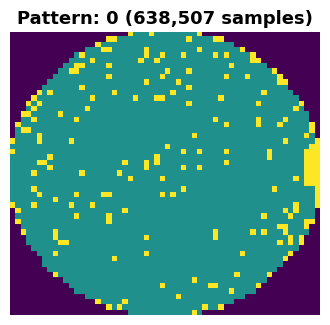

------------------------------------------------------------

[ 🔍 Pattern : none ]
  해당 패턴 총 데이터 개수: 147,431개
  - lotName (로트 이름)       : lot1
  - waferIndex (고유번호)     : 1.0
  - dieSize (총 칩의 개수)    : 1683.0
  - trainTestLabel (용도)     : Training
  - waferMap 행렬 크기        : (45, 48)
  - 행렬 내 고유 숫자         : [0 1 2] (0:배경, 1:정상, 2:불량)


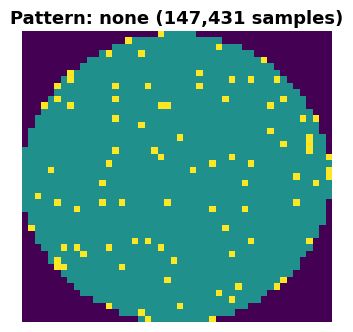

------------------------------------------------------------

[ 🔍 Pattern : Edge-Ring ]
  해당 패턴 총 데이터 개수: 9,680개
  - lotName (로트 이름)       : lot5
  - waferIndex (고유번호)     : 1.0
  - dieSize (총 칩의 개수)    : 2460.0
  - trainTestLabel (용도)     : Training
  - waferMap 행렬 크기        : (53, 58)
  - 행렬 내 고유 숫자         : [0 1 2] (0:배경, 1:정상, 2:불량)


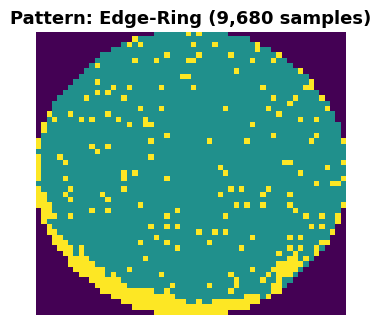

------------------------------------------------------------

[ 🔍 Pattern : Edge-Loc ]
  해당 패턴 총 데이터 개수: 5,189개
  - lotName (로트 이름)       : lot2
  - waferIndex (고유번호)     : 12.0
  - dieSize (총 칩의 개수)    : 2460.0
  - trainTestLabel (용도)     : Training
  - waferMap 행렬 크기        : (53, 58)
  - 행렬 내 고유 숫자         : [0 1 2] (0:배경, 1:정상, 2:불량)


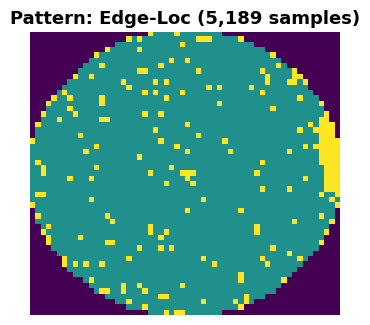

------------------------------------------------------------

[ 🔍 Pattern : Center ]
  해당 패턴 총 데이터 개수: 4,294개
  - lotName (로트 이름)       : lot2
  - waferIndex (고유번호)     : 20.0
  - dieSize (총 칩의 개수)    : 2460.0
  - trainTestLabel (용도)     : Training
  - waferMap 행렬 크기        : (53, 58)
  - 행렬 내 고유 숫자         : [0 1 2] (0:배경, 1:정상, 2:불량)


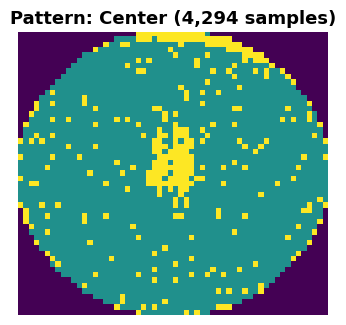

------------------------------------------------------------

[ 🔍 Pattern : Loc ]
  해당 패턴 총 데이터 개수: 3,593개
  - lotName (로트 이름)       : lot1
  - waferIndex (고유번호)     : 20.0
  - dieSize (총 칩의 개수)    : 1683.0
  - trainTestLabel (용도)     : Training
  - waferMap 행렬 크기        : (45, 48)
  - 행렬 내 고유 숫자         : [0 1 2] (0:배경, 1:정상, 2:불량)


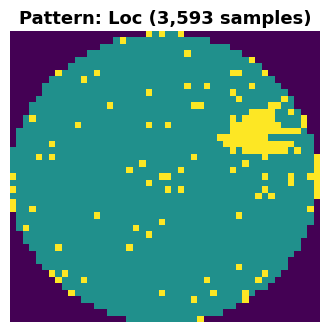

------------------------------------------------------------

[ 🔍 Pattern : Scratch ]
  해당 패턴 총 데이터 개수: 1,193개
  - lotName (로트 이름)       : lot6
  - waferIndex (고유번호)     : 10.0
  - dieSize (총 칩의 개수)    : 2460.0
  - trainTestLabel (용도)     : Training
  - waferMap 행렬 크기        : (53, 58)
  - 행렬 내 고유 숫자         : [0 1 2] (0:배경, 1:정상, 2:불량)


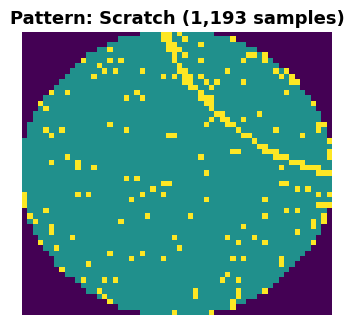

------------------------------------------------------------

[ 🔍 Pattern : Random ]
  해당 패턴 총 데이터 개수: 866개
  - lotName (로트 이름)       : lot25
  - waferIndex (고유번호)     : 3.0
  - dieSize (총 칩의 개수)    : 533.0
  - trainTestLabel (용도)     : Training
  - waferMap 행렬 크기        : (26, 26)
  - 행렬 내 고유 숫자         : [0 1 2] (0:배경, 1:정상, 2:불량)


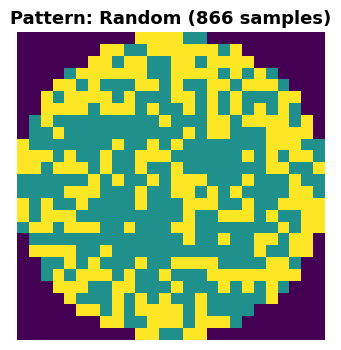

------------------------------------------------------------

[ 🔍 Pattern : Donut ]
  해당 패턴 총 데이터 개수: 555개
  - lotName (로트 이름)       : lot490
  - waferIndex (고유번호)     : 13.0
  - dieSize (총 칩의 개수)    : 1091.0
  - trainTestLabel (용도)     : Training
  - waferMap 행렬 크기        : (37, 37)
  - 행렬 내 고유 숫자         : [0 1 2] (0:배경, 1:정상, 2:불량)


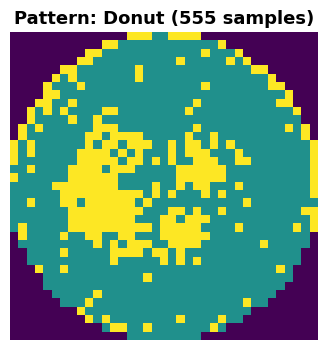

------------------------------------------------------------

[ 🔍 Pattern : Near-full ]
  해당 패턴 총 데이터 개수: 149개
  - lotName (로트 이름)       : lot38
  - waferIndex (고유번호)     : 5.0
  - dieSize (총 칩의 개수)    : 533.0
  - trainTestLabel (용도)     : Training
  - waferMap 행렬 크기        : (26, 26)
  - 행렬 내 고유 숫자         : [0 1 2] (0:배경, 1:정상, 2:불량)


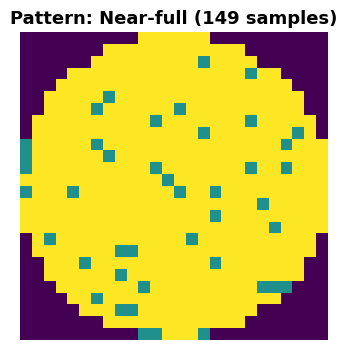

------------------------------------------------------------


In [5]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_label(x):
    """
    불규칙한 failureType 데이터를 안전하게 평탄화(Flattening)하는 함수
    """
    if x is None or (isinstance(x, (np.ndarray, list)) and len(x) == 0):
        return 'none'
    if isinstance(x, (np.ndarray, list)):
        if isinstance(x[0], (np.ndarray, list)) and len(x[0]) > 0:
            return str(x[0][0])
        else:
            return str(x[0])
    return str(x)

def main():
    # ==========================================
    # [0단계] Google Drive 마운트
    # ==========================================
    drive.mount('/content/drive')

    file_path = '/content/drive/MyDrive/ACK2026_Wafer/MIR-WM811K/MIR-WM811K/Python/WM811K.pkl'

    # ==========================================
    # [1단계] 데이터 로드 및 기본 구조 파악
    # ==========================================
    print("\n1. 데이터 로드")
    try:
        df = pd.read_pickle(file_path)
    except FileNotFoundError:
        print(f"오류: 지정된 경로({file_path})에서 파일을 찾을 수 없습니다.")
        return

    print("=== [1단계] 데이터셋 기본 구조 ===")
    print(f"- 전체 웨이퍼 데이터 개수: {len(df):,}개")
    print(f"- 데이터 항목(컬럼): {list(df.columns)}\n")

    # ==========================================
    # [2단계] 데이터 라벨 평탄화 및 개수 집계
    # ==========================================
    print("2. 데이터 라벨 평탄화")
    df['failureType'] = df['failureType'].apply(extract_label)

    # 패턴별 총 데이터 개수를 집계 (개수가 많은 순서대로 자동 정렬됨)
    defect_counts = df['failureType'].value_counts()
    print("-" * 60)

    # ==========================================
    # [3단계] 각 패턴별 1개 샘플 상세 분석 및 시각화
    # ==========================================
    print("\n=== [3단계] 각 패턴별 웨이퍼 샘플 분석 및 시각화 ===")

    for label in defect_counts.index:
        # 해당 결함 패턴과 일치하는 데이터 중 첫 번째 샘플 추출
        sample = df[df['failureType'] == label].iloc[0]
        wafer_map = sample['waferMap']

        # 현재 패턴의 총 개수 추출
        total_count = defect_counts[label]

        # 텍스트 정보 출력
        print(f"\n[ 🔍 Pattern : {label} ]")
        print(f"  해당 패턴 총 데이터 개수: {total_count:,}개") # 추가된 개수 출력 부분
        print(f"  - lotName (로트 이름)       : {sample['lotName']}")
        print(f"  - waferIndex (고유번호)     : {sample['waferIndex']}")
        print(f"  - dieSize (총 칩의 개수)    : {sample['dieSize']}")
        print(f"  - trainTestLabel (용도)     : {sample['trainTestLabel']}")
        print(f"  - waferMap 행렬 크기        : {wafer_map.shape}")
        print(f"  - 행렬 내 고유 숫자         : {np.unique(wafer_map)} (0:배경, 1:정상, 2:불량)")

        # 이미지 시각화 (Colab Inline 출력)
        plt.figure(figsize=(4, 4))
        plt.imshow(wafer_map, cmap='viridis')
        plt.title(f"Pattern: {label} ({total_count:,} samples)", fontsize=13, fontweight='bold')
        plt.axis('off')

        plt.show()
        print("-" * 60)

if __name__ == "__main__":
    main()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

1. 데이터 로드
=== [1단계] 데이터셋 기본 구조 ===
- 전체 웨이퍼 데이터 개수: 25,519개
- 데이터 항목(컬럼): ['dieSize', 'failureType', 'lotName', 'trainTestLabel', 'waferIndex', 'waferMap']

2. 데이터 라벨 평탄화
------------------------------------------------------------

=== [3단계] 각 패턴별 웨이퍼 샘플 분석 및 시각화 ===

[ 🔍 Pattern : Edge-Ring ]
  해당 패턴 총 데이터 개수: 9,680개
  - lotName (로트 이름)       : lot5
  - waferIndex (고유번호)     : 1.0
  - dieSize (총 칩의 개수)    : 2460.0
  - trainTestLabel (용도)     : Training
  - waferMap 행렬 크기        : (53, 58)
  - 행렬 내 고유 숫자         : [0 1 2] (0:배경, 1:정상, 2:불량)


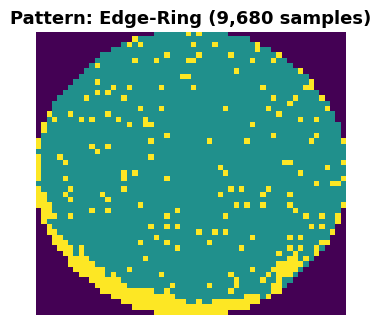

------------------------------------------------------------

[ 🔍 Pattern : Edge-Loc ]
  해당 패턴 총 데이터 개수: 5,189개
  - lotName (로트 이름)       : lot2
  - waferIndex (고유번호)     : 12.0
  - dieSize (총 칩의 개수)    : 2460.0
  - trainTestLabel (용도)     : Training
  - waferMap 행렬 크기        : (53, 58)
  - 행렬 내 고유 숫자         : [0 1 2] (0:배경, 1:정상, 2:불량)


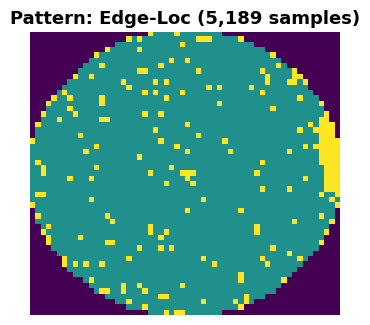

------------------------------------------------------------

[ 🔍 Pattern : Center ]
  해당 패턴 총 데이터 개수: 4,294개
  - lotName (로트 이름)       : lot2
  - waferIndex (고유번호)     : 20.0
  - dieSize (총 칩의 개수)    : 2460.0
  - trainTestLabel (용도)     : Training
  - waferMap 행렬 크기        : (53, 58)
  - 행렬 내 고유 숫자         : [0 1 2] (0:배경, 1:정상, 2:불량)


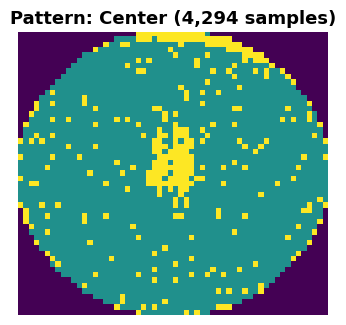

------------------------------------------------------------

[ 🔍 Pattern : Loc ]
  해당 패턴 총 데이터 개수: 3,593개
  - lotName (로트 이름)       : lot1
  - waferIndex (고유번호)     : 20.0
  - dieSize (총 칩의 개수)    : 1683.0
  - trainTestLabel (용도)     : Training
  - waferMap 행렬 크기        : (45, 48)
  - 행렬 내 고유 숫자         : [0 1 2] (0:배경, 1:정상, 2:불량)


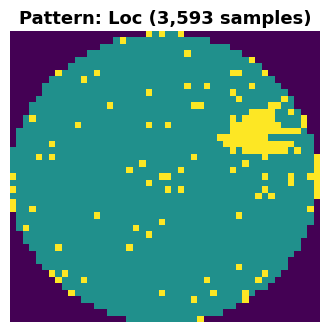

------------------------------------------------------------

[ 🔍 Pattern : Scratch ]
  해당 패턴 총 데이터 개수: 1,193개
  - lotName (로트 이름)       : lot6
  - waferIndex (고유번호)     : 10.0
  - dieSize (총 칩의 개수)    : 2460.0
  - trainTestLabel (용도)     : Training
  - waferMap 행렬 크기        : (53, 58)
  - 행렬 내 고유 숫자         : [0 1 2] (0:배경, 1:정상, 2:불량)


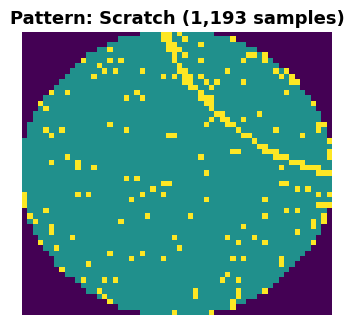

------------------------------------------------------------

[ 🔍 Pattern : Random ]
  해당 패턴 총 데이터 개수: 866개
  - lotName (로트 이름)       : lot25
  - waferIndex (고유번호)     : 3.0
  - dieSize (총 칩의 개수)    : 533.0
  - trainTestLabel (용도)     : Training
  - waferMap 행렬 크기        : (26, 26)
  - 행렬 내 고유 숫자         : [0 1 2] (0:배경, 1:정상, 2:불량)


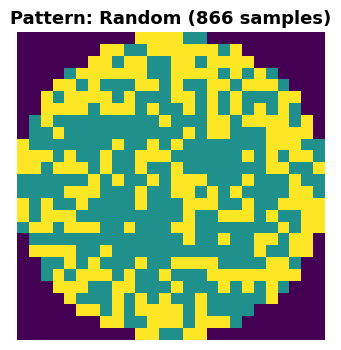

------------------------------------------------------------

[ 🔍 Pattern : Donut ]
  해당 패턴 총 데이터 개수: 555개
  - lotName (로트 이름)       : lot490
  - waferIndex (고유번호)     : 13.0
  - dieSize (총 칩의 개수)    : 1091.0
  - trainTestLabel (용도)     : Training
  - waferMap 행렬 크기        : (37, 37)
  - 행렬 내 고유 숫자         : [0 1 2] (0:배경, 1:정상, 2:불량)


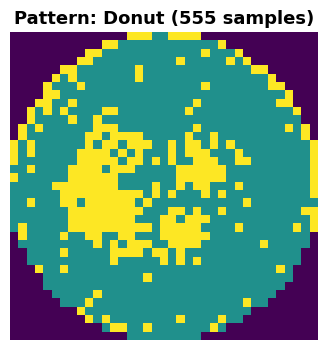

------------------------------------------------------------

[ 🔍 Pattern : Near-full ]
  해당 패턴 총 데이터 개수: 149개
  - lotName (로트 이름)       : lot38
  - waferIndex (고유번호)     : 5.0
  - dieSize (총 칩의 개수)    : 533.0
  - trainTestLabel (용도)     : Training
  - waferMap 행렬 크기        : (26, 26)
  - 행렬 내 고유 숫자         : [0 1 2] (0:배경, 1:정상, 2:불량)


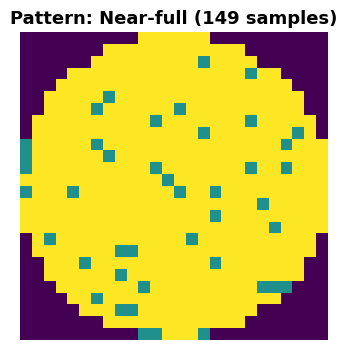

------------------------------------------------------------


In [6]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_label(x):
    """
    불규칙한 failureType 데이터를 안전하게 평탄화(Flattening)하는 함수
    """
    if x is None or (isinstance(x, (np.ndarray, list)) and len(x) == 0):
        return 'none'
    if isinstance(x, (np.ndarray, list)):
        if isinstance(x[0], (np.ndarray, list)) and len(x[0]) > 0:
            return str(x[0][0])
        else:
            return str(x[0])
    return str(x)

def main():
    # ==========================================
    # [0단계] Google Drive 마운트
    # ==========================================
    drive.mount('/content/drive')

    file_path = '/content/drive/MyDrive/ACK2026_Wafer/MIR-WM811K/MIR-WM811K/Python/WM811K_defects.pkl'

    # ==========================================
    # [1단계] 데이터 로드 및 기본 구조 파악
    # ==========================================
    print("\n1. 데이터 로드")
    try:
        df = pd.read_pickle(file_path)
    except FileNotFoundError:
        print(f"오류: 지정된 경로({file_path})에서 파일을 찾을 수 없습니다.")
        return

    print("=== [1단계] 데이터셋 기본 구조 ===")
    print(f"- 전체 웨이퍼 데이터 개수: {len(df):,}개")
    print(f"- 데이터 항목(컬럼): {list(df.columns)}\n")

    # ==========================================
    # [2단계] 데이터 라벨 평탄화 및 개수 집계
    # ==========================================
    print("2. 데이터 라벨 평탄화")
    df['failureType'] = df['failureType'].apply(extract_label)

    # 패턴별 총 데이터 개수를 집계 (개수가 많은 순서대로 자동 정렬됨)
    defect_counts = df['failureType'].value_counts()
    print("-" * 60)

    # ==========================================
    # [3단계] 각 패턴별 1개 샘플 상세 분석 및 시각화
    # ==========================================
    print("\n=== [3단계] 각 패턴별 웨이퍼 샘플 분석 및 시각화 ===")

    for label in defect_counts.index:
        # 해당 결함 패턴과 일치하는 데이터 중 첫 번째 샘플 추출
        sample = df[df['failureType'] == label].iloc[0]
        wafer_map = sample['waferMap']

        # 현재 패턴의 총 개수 추출
        total_count = defect_counts[label]

        # 텍스트 정보 출력
        print(f"\n[ 🔍 Pattern : {label} ]")
        print(f"  해당 패턴 총 데이터 개수: {total_count:,}개") # 추가된 개수 출력 부분
        print(f"  - lotName (로트 이름)       : {sample['lotName']}")
        print(f"  - waferIndex (고유번호)     : {sample['waferIndex']}")
        print(f"  - dieSize (총 칩의 개수)    : {sample['dieSize']}")
        print(f"  - trainTestLabel (용도)     : {sample['trainTestLabel']}")
        print(f"  - waferMap 행렬 크기        : {wafer_map.shape}")
        print(f"  - 행렬 내 고유 숫자         : {np.unique(wafer_map)} (0:배경, 1:정상, 2:불량)")

        # 이미지 시각화 (Colab Inline 출력)
        plt.figure(figsize=(4, 4))
        plt.imshow(wafer_map, cmap='viridis')
        plt.title(f"Pattern: {label} ({total_count:,} samples)", fontsize=13, fontweight='bold')
        plt.axis('off')

        plt.show()
        print("-" * 60)

if __name__ == "__main__":
    main()